# 0 - Introduction
This is tutorial follows the cookbook from H\"oelmer 2026 for simulating polymer-attenuated Coulombic self-assembly. Each section of this tutorial details the most important parameters for running simulations similar to those specified in the Cookbook.

# A - Nucleation

It is harder to observe and simulate nucleation at a scale where quantum mechanics plays a large role than at a scale where it does not. From observing nucleation of colloidal crystals, one can gain fundamental insights into nucleation and determine the kinetic feasiblity of crystal polymorphs.

Before simulating, key quantities to examine for any given system are the intergrator parameters, universal potential parameters, and individual particle parameters to ensure the system. For the potential and  of these parameters correspond to physical quantities. For an explanation of each of the physical quantities reference Hueckel 2020.

Notably, the temperature and potential temperature are specified separately. Potential temperture refers to any temperature in an interparticle potential, such as T highlighted in red below.

$$
    V_E = 2k_B\color{red}T\color{none}\pi\epsilon r\psi_1\psi_2\exp(-h/\lambda_D)
$$

Whereas, the temperature supplied in the intergator parameters refers to any temperature supplied to the integrator function. In the case of the Verlet algorithm, the velocity update function is as follows.

$$
    m_i \frac{d\mathbf{v}_i}{dt} = \mathbf{f_i} - \gamma m_i \mathbf{v}_i + N(0, 2\gamma k_B \color{red}T\color{none})
$$

Where $\mathbf{v}_i$ is the velocity on the $i^{th}$ particle, gamma is the friction coefficient (also specified in the integrator parameters), $m_i$ is the mass of the $i^{th}$ particle, $\mathbf{f_i}$ is the force on that particle, and $N(\mu, \sigma^2)$ is a normal distribution with mean $\mu$ and variance $\sigma^2$

These two temperatures need not be the same in principle, but selecting different values for them may generate non-physical results.

### I - Integrator Parameters

The integrator parameters are used in the integrator algorithm. The main difference between the various integrators comes in their velocity update step. The velocity update step for the Langevin Integrator is shown below with each of the integrator parameters highlighted.

$$
    m_i \frac{d\mathbf{v}_i}{\color{red}dt\color{none}} = \mathbf{f_i} - \color{orange}\gamma\color{none} m_i \mathbf{v}_i + N(0, 2\color{orange}\gamma\color{none} k_B \color{yellow}T\color{none})
$$

- integrator: LangevinIntegrator

- integrator_parameters:
  - randomNumberSeed: 1

<font color=red>

  - stepSize: !Quantity
    - unit: picosecond
    - value: 0.00317647015905543
  
<font color=orange>

  - frictionCoeff: !Quantity
    - unit: /picosecond
    - value: 0.001574074286750681

<font color=yellow>

  - temperature: !Quantity
    - unit: kelvin
    - value: 298.0

## II - Potential Parameters
Potential parameters are exculsively used in potentials, the screened coulombic potential between two charged particles and the Alexander de Gennes polymer brush model that together define PACS are given as an example potential that incorporates all of the specified potential parameters.

$$
    V_E = 2k_B\color{red}T\color{none}\pi\color{orange}\epsilon\color{none} r\psi_1\psi_2\exp(-h/\color{yellow}\lambda_D\color{none})
$$
$$
    V_P = \frac{16k_B\color{red}T\color{none} \pi L^2 \color{green}\sigma\color{none}^{\frac{3}{2}}}{35}\left[28\left(\left(\frac{h}{2\color{blue}L\color{none}}\right)^{-\frac{1}{4}}-1\right) + \frac{20}{11}\left(1-\left(\frac{h}{2\color{blue}L\color{none}}\right)^{\frac{11}{4}}+12\left(\frac{h}{2\color{blue}L\color{none}}-1\right)\right)\right]
$$

<font color=red>

- potential_temperature: !Quantity
  - unit: kelvin
  - value: 298.0

<font color=orange>

- dielectric_constant: 80.0

<font color=yellow>

- debye_length: !Quantity
  - unit: nanometer
  - value: 5.0483

<font color=green>

- brush_density: !Quantity
  - unit: /(nanometer**2)
  - value: 0.09

<font color=blue>

- brush_length: !Quantity
  - unit: nanometer
  - value: 10.0



## III - Individual Particle Parameters

Individual particle parameters are used in the potentials for each particle, except for mass which is used in the integrator

$$
    \color{red}m_i\color{none} \frac{d\mathbf{v}_i}{dt} = \mathbf{f_i} - \gamma \color{red}m_i\color{none} \mathbf{v}_i + N(0, 2\gamma k_B T)
$$
$$
    V_E = 2k_BT\pi\epsilon \color{orange}r\color{none}\color{yellow}\psi_1\psi_2\color{none}\exp(-h/\lambda_D)
$$

<font color=red>

- masses:
    - "1": !Quantity
        - unit: dalton
        - value: 1.24898
    - "2": !Quantity
        - unit: dalton
        - value: 1.0

<font color=orange>

- radii:
    - "1": !Quantity
        - unit: nanometer
        - value: 105.0
    - "2": !Quantity
        - unit: nanometer
        - value: 97.5
        
<font color=yellow>

- surface_potentials:
    - "1": !Quantity
        - unit: millivolt
        - value: -50.0
    - "2": !Quantity
        - unit: millivolt
        - value: 50.0

#  - Substrates



# - Plumed

Plumed is a useful plugin for molecular dynamics simulations that allows for on-the-fly calculation of collective variables as well as enhanced sampling and free energy methods. Our PACSim software interfaces with plumed via the openmm-plumed plugin. We illustrate this functionality by calculating the mean coordination number of the colloidal particles in a molecular dynamics simulation, where the system starts in the gas phase and forms a crystal. 

To interface with Plumed, one must set `use_plumed` to "True" in the yaml input file. One must also have a separate plumed input file whose filename is specified via the `plumed_script` parameter in the yaml input file. The plumed input file follows the format described in the Plumed documentation, which can be found [here ](https://www.plumed.org/doc-v2.10/user-doc/html/index.html). Coordination number is just one of many possible collective variables that can be computed on-the-fly in a simulation. Many others are available within Plumed's multicolvar module.

In our example, we use a 432-particle binary system with negative (N) and positive (P) particles in a 1:1 ratio and we choose a pair potential interaction strength that facilitates crystal nucleation.

Below are the contents of a plumed input file that computes the coordination number of all particles with themselves, the coordination number of N particles with N particles, the coordination number of P particles with P particles, and the coordination number of N particles with P particles, respectively. All use an exponential switching function. The mean value of each of these collective variables is printed to a file called colvars every 10000 steps of the simulation.

```
UNITS LENGTH=nm TIME=ps ENERGY=kj/mol
#https://www.plumed.org/doc-master/user-doc/html/COORDINATIONNUMBER/

c_all: COORDINATIONNUMBER SPECIES=@mdatoms                  SWITCH={EXP D_0=300.0 R_0=50 D_MAX=600} MEAN
c_N_N: COORDINATIONNUMBER SPECIESA=1-432:2 SPECIESB=1-432:2 SWITCH={EXP D_0=300.0 R_0=50 D_MAX=600} MEAN
c_P_P: COORDINATIONNUMBER SPECIESA=2-432:2 SPECIESB=2-432:2 SWITCH={EXP D_0=300.0 R_0=50 D_MAX=600} MEAN
c_N_P: COORDINATIONNUMBER SPECIESA=1-432:2 SPECIESB=2-432:2 SWITCH={EXP D_0=300.0 R_0=50 D_MAX=600} MEAN

PRINT ARG=c_all.mean,c_N_N.mean,c_P_P.mean,c_N_P.mean, FILE=colvars STRIDE=10000
```

We vary the Debye screening length parameter slightly and show the mean coordination number of all particles as a function of simulation time under each condition. As the Debye screening length increases and the pair potential grows stronger, for this particular system, we observe that the nucleation occurs sooner and the mean coordination number increases more sharply at the beginning of the simulation, as can be seen in the plot below.

All input files for these simulations can be found in the directory [`colloids/cookbook/Plumed/`](colloids/cookbook/Plumed/).

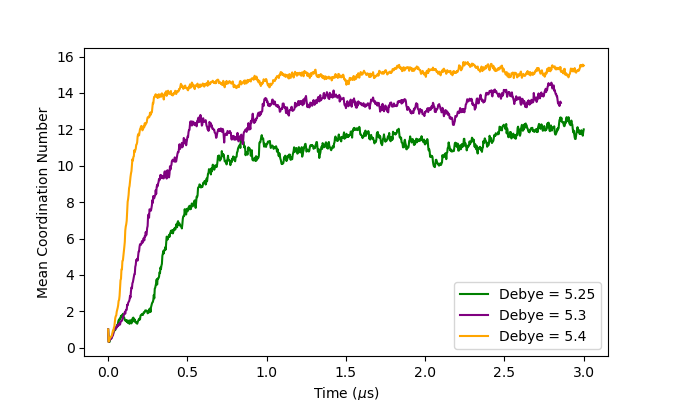

# - Metadynamics

In addition to calculating the value of a collective variable on-the-fly during a simulation, the Plumed plugin can be used to run enhanced sampling molecular dynamics simulations by adding bias along a collective variable. In terms of the logistics of running such a simulation with our PACSim software, the inputs are exactly the same, but here the plumed input file includes additional information to specify the bias.

We illustrate this functionality by running a simple well-tempered metadynamics simulation on the same binary 432-particle system, biasing along the mean coordination number of all particles. Below are the contents of the plumed input file that defines the coordination number collective variable as described above, and then specifies to bias this variable in metadynamics. The hill height (HEIGHT), Gaussian width (SIGMA), bias factor (BIASFACTOR), and temperature (TEMP) must be specified for well-tempered metadynamics.

```
UNITS LENGTH=nm TIME=ps ENERGY=kj/mol
c_all: COORDINATIONNUMBER SPECIES=@mdatoms SWITCH={EXP D_0=300.0 R_0=50 D_MAX=600} MEAN

METAD ...
  ARG=c_all.mean
  CALC_RCT
  HEIGHT=1.0
  BIASFACTOR=50
  SIGMA=0.5
  PACE=100
  TEMP=300
  GRID_MIN=0
  GRID_MAX=20
  GRID_BIN=201
  GRID_WFILE=grid.dat
  FILE=hills.dat
  GRID_WSTRIDE=10000
  LABEL=metad
  STRIDE=2
... METAD

PRINT ARG=c_all.mean,metad.* FILE=bias STRIDE=10000
```

We observe that the system crystallizes and then melts several times within a 3 microsecond simulation. A plot of the mean coordination number versus simulation time illustrates the fluctuation of coordination number as the crystallization and melting processes occur.

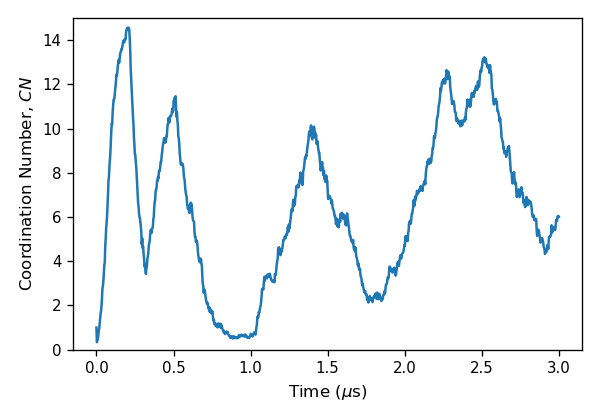

All input files for these simulations can be found in the directory [`colloids/cookbook/Metadynamics/`](colloids/cookbook/Metadynamics/).
